# 03 Test Environment Simulated Aneling Algorithm

This notebook is to serve as a test ground for building an numerical shortest path optimiser following building a terrain we now will build a optimiser to solve this. I will use a simulated annealing algorithm. First lets initialise the terrain.

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("../src")
from terrain.terrain import Terrain
from geometry.endpoints import Endpoints
from geometry.path import Path
from geometry.generators import straight_line_path


### terrain ### 
terrain = Terrain(
    width=100,
    height=100,
    resolution=100,
    cost=0.1
)

terrain.add_hill(
    centre=(50, 50),
    peak_cost=10,
    radius=20

)


### boundarys ###

boundary = Endpoints(
    start=(10, 20),
    end=(80, 80)
)

boundary_df = boundary.to_dataframe()


terrain.grid.shape
terrain_df = terrain.to_dataframe()

### Initial Path
initial_path = straight_line_path(
    start=boundary.start,
    end=boundary.end,
    num_points=100
)

initial_path_df = initial_path.to_dataframe()

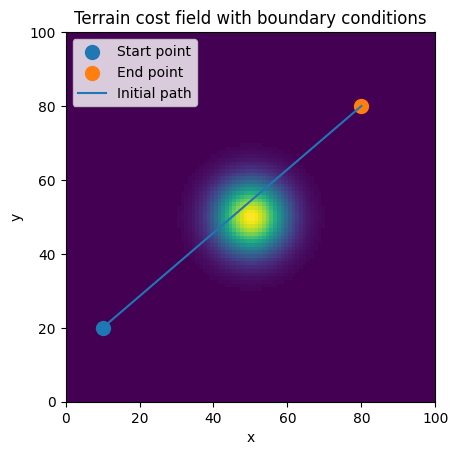

In [2]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    initial_path_df["x"],
    initial_path_df["y"],
    label="Initial path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

I am wanting to minimise this cost function

In [3]:
from cost_functions.terrain_cost import terrain_cost

cost = terrain_cost(
    initial_path,
    terrain
)

print(cost)

156.09657794974427


I have a function that performs a random shift move on an interior path segment this will give me a number of candiate paths

I then apply a simulated annealing algo to optimise for best solution

In [4]:
from optimisation.annealing import simulated_annealing, path_history_to_df


best_path, best_cost, history, path_history = simulated_annealing(
    initial_path=initial_path,
    terrain=terrain,
    iterations=10000,
    initial_temperature=5,
    cooling_rate=0.995,
    sigma=0.1,
    alpha=10
)

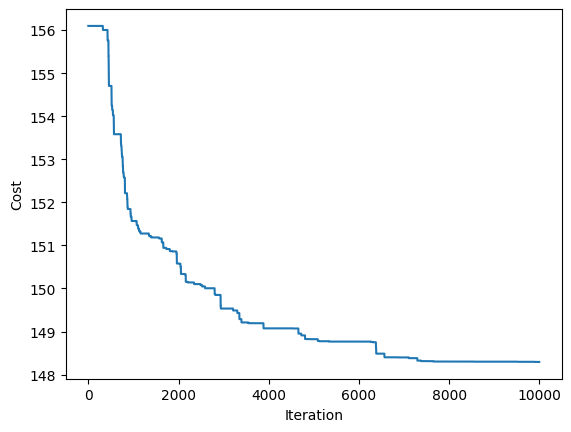

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

plt.plot(
    history_df["best_cost"]
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [6]:

best_path_df = best_path.to_dataframe()

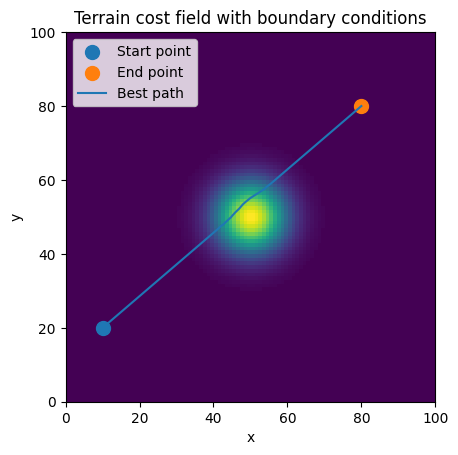

In [7]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    best_path_df["x"],
    best_path_df["y"],
    label="Best path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [8]:
from optimisation.annealing import simulated_segment_annealing


best_path_segment, best_cost_segment, history_segment, path_history_segment = simulated_segment_annealing(
    initial_path=initial_path,
    terrain=terrain,
    iterations=10000,
    initial_temperature=5,
    cooling_rate=0.995,
    sigma=0.3,
    alpha=10
)


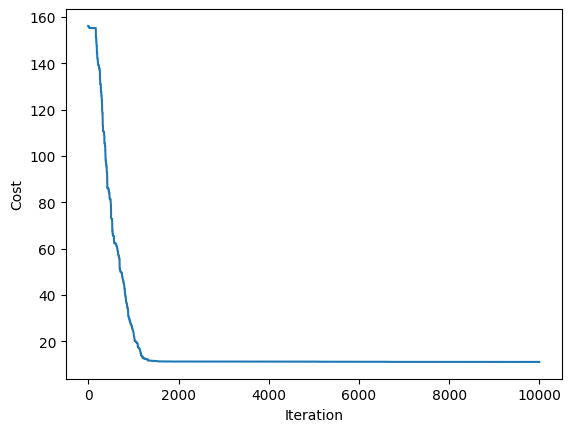

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

history_segment_df = pd.DataFrame(history_segment)

plt.plot(
    history_segment_df["best_cost"]
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [10]:

best_path_segment_df = best_path_segment.to_dataframe()


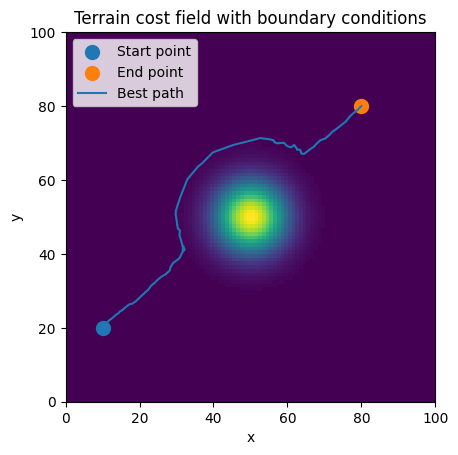

In [11]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    best_path_segment_df["x"],
    best_path_segment_df["y"],
    label="Best path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [12]:
print(best_path_segment_df.to_string(index=False))

 point         x         y
     0 10.000000 20.000000
     1 10.770947 20.813850
     2 11.297544 21.582006
     3 12.004614 22.188066
     4 12.546000 22.578796
     5 13.673447 23.564203
     6 14.316641 23.962475
     7 14.727051 24.463527
     8 15.313196 24.778370
     9 16.108353 25.472159
    10 16.718352 25.953822
    11 17.324141 26.386751
    12 17.995972 26.495670
    13 19.097432 27.258433
    14 19.555395 27.731315
    15 19.939161 28.082426
    16 20.747514 28.861619
    17 22.389945 30.370599
    18 23.113634 31.366478
    19 24.147411 32.233320
    20 24.811291 32.903240
    21 25.841599 33.789140
    22 26.125684 33.932335
    23 26.609208 34.281628
    24 26.961981 34.378513
    25 27.251795 34.696845
    26 27.635628 35.023066
    27 28.160304 35.500875
    28 28.350143 36.349326
    29 29.092236 37.567476
    30 30.259755 38.397405
    31 30.838563 38.903525
    32 31.373248 40.033524
    33 31.644568 40.523460
    34 31.842331 40.828072
    35 32.052474 40.899448
 